<a href="https://colab.research.google.com/github/JansJam/microbotics_pose_depth_estimation/blob/main/microbotics_post_depth_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pose Classification and Depth Estimation for Microbots

### Notebook Overview

This Google Colab Notebook implements a unified model CNN model for pose classification and depth estimation. For this task we propose our own architecture called PoseDepthNet, that uses a custom classification and regression head for the classification and regression tasks. We compare the performance of PoseDepthNet with pretrained models Resnet-18 and MobileNetV3, also incorporating custom heads to perform these tasks. A combined loss function using Cross Entropy and MSE was used to train all models. In order to balance model training to optimise loss between the classification and regression tasks evenly, a grid search was performed to determine the weights of the Cross Entropy and MSE functions during model training. Finally after training all three models, we evaluate the models performance using classification accuracy, confusion matrices, RMSE, and other metrics

We start by important all relevent libraries and frameworks

In [ ]:
# OS and file handling
import os
import zipfile
import h5py
from google.colab import drive

# Image handling and computer vision
import cv2
from PIL import Image

# Plotting and visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Data handling and analysis
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

# PyTorch and deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau


# Data Preparation

### Data Loading and Verification
The dataset for the project was initially stored in a compressed zip file, `Database.zip`, within Google Drive. The dataset was accessed and extracted programmatically using Python. The following steps ensured proper data handling:
1. **File Verification**: The existence of the zip file in the specified path was confirmed to prevent errors.
2. **Unzipping the Dataset**: The dataset was extracted to a local directory (`./Database`) using Python's `zipfile` module.

### File Organization
The extracted dataset included two main components:
1. `Label.txt`: A text file containing annotations for each image, detailing pose classification, rotation, and depth estimation labels.
2. `Image/`: A directory housing the image files associated with the labels.

### Sample Exploration
To confirm the dataset's integrity and structure:
- The first five entries from `Label.txt` were read and displayed to validate label formatting and content.
- The `Image/` directory was explored to ensure proper extraction of image files.
- The first image in the directory was loaded and displayed using `Pillow` and `Matplotlib`, visually verifying the dataset's content.


In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Database.zip found!
['Label.txt', 'Image']
            FileName  Pitch  Roll     Depth
0  6_P0_R0_00001.jpg      0     0  0.611818
1  6_P0_R0_00002.jpg      0     0  0.693017
2  6_P0_R0_00003.jpg      0     0  0.457814
3  6_P0_R0_00004.jpg      0     0  0.105780
4  6_P0_R0_00005.jpg      0     0  0.296676
['6_P0_R0_00001.jpg', '6_P0_R0_00002.jpg', '6_P0_R0_00003.jpg', '6_P0_R0_00004.jpg', '6_P0_R0_00005.jpg']


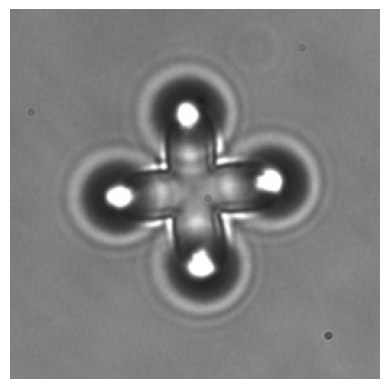

In [ ]:
# Path to the zip file in Google Drive
dataset_path = '/content/drive/MyDrive/Database.zip'

# Verify the file exists
if os.path.exists(dataset_path):
    print("Database.zip found!")
else:
    print("Database.zip not found. Check the path.")

# Unzip the file
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('./Database')

# List the contents of the extracted folder
print(os.listdir('./Database'))

# Load the label file
label_path = './Database/Label.txt'

# Correctly parse the Label.txt file
columns = ['FileName', 'Pitch', 'Roll', 'Depth']
labels = pd.read_csv(label_path, sep=" ", header=None, names=columns)

# Display first 5 rows of the labels
print(labels.head())

# Load and display the first image
image_dir = './Database/Image'
image_files = os.listdir(image_dir)

# Ensure image files are sorted for consistent results
image_files.sort()

print(image_files[:5])  # List first 5 image files

# Display the first image
image_path = os.path.join(image_dir, image_files[0])
img = Image.open(image_path)

plt.imshow(img)
plt.axis('off')
plt.show()

# Data Exploration

Data explorations shows that there are 8 discrete classes for Pitch and Roll, representing the angle the Microbot is facing on its lateral and longitudinal axis respectively. Additionally, all depth values are within a range of 0 and 1 inclusive. Data normalisation may be unecessary for the Depth column.

The label distribution of `Pitch`, `Roll` and `Depth` are plotted on histograms. The mean and standard deviation are also calculated for each label. Analysis of Pitch, Roll and Depth distribution are as follows:

### Pitch Label Distribution

Overall the Pitch Label distribution is unbalanced, with the minorty class at `Pitch = 70` and the majority class at `Pitch = 0`. As the pitch increases, the number of samples for each class also increases.

### Roll Label Distribution

The Roll class is also unbalanced, but the distribution is reversed compared to Pitch. The minority class for Roll is at `Roll = 0` and the majority class is at `Roll = 70`

### Depth Label Distribution

Overall the depth of Microbots are generally evenly distributed. This is especially true at depth ranges between 0.1 to 0.9, as the histogram shows that data samples grouped within intervals of 0.05 are almost all within a range of 50 to 100 samples. However, one issue


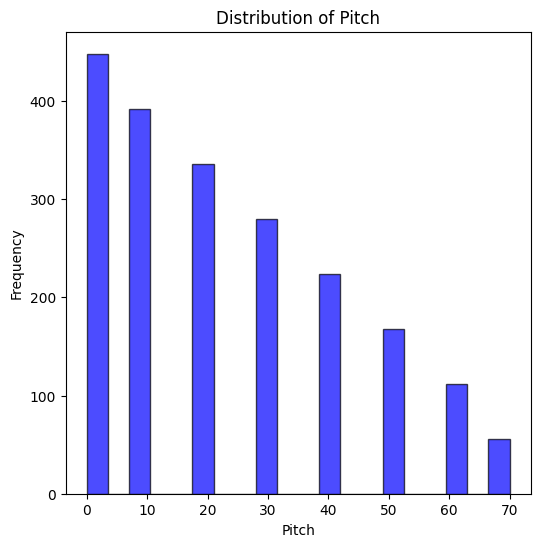

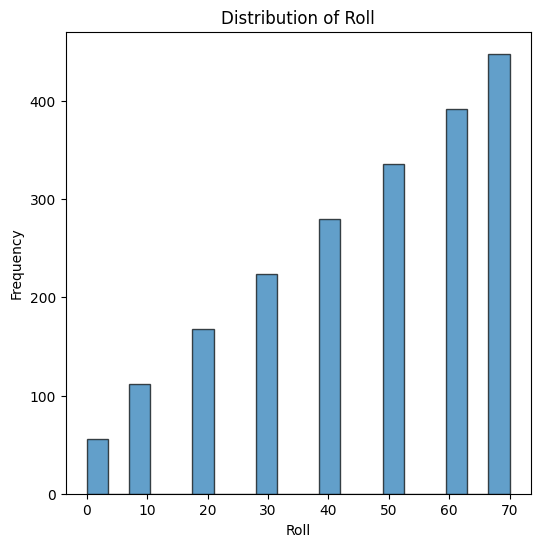

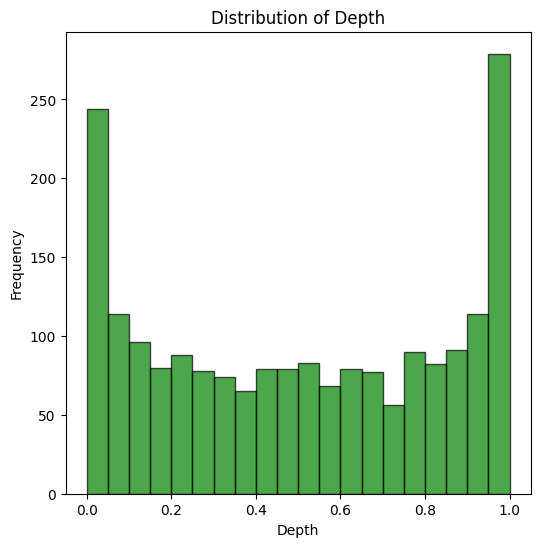

          Pitch       Roll     Depth
mean  23.333333  46.666667  0.506819
std   19.725159  19.725159  0.341972


In [ ]:
# Generate histograms for Pitch, Roll, and Depth
# Plot for Pitch
plt.figure(figsize=(6, 6))
plt.hist(labels['Pitch'], bins=20, edgecolor='k', alpha=0.7, color='blue')
plt.title('Distribution of Pitch')
plt.xlabel('Pitch')
plt.ylabel('Frequency')
plt.show()

# Plot for Roll
plt.figure(figsize=(6, 6))
plt.hist(labels['Roll'], bins=20, edgecolor='k', alpha=0.7)
plt.title('Distribution of Roll')
plt.xlabel('Roll')
plt.ylabel('Frequency')
plt.show()

# Plot for Depth
plt.figure(figsize=(6, 6))
plt.hist(labels['Depth'], bins=20, edgecolor='k', alpha=0.7, color='green')
plt.title('Distribution of Depth')
plt.xlabel('Depth')
plt.ylabel('Frequency')
plt.show()

# Calculate mean and standard deviation
stats = labels[['Pitch', 'Roll', 'Depth']].agg(['mean', 'std'])
print(stats)

Three functions are used to visualise data samples for a dataset of microscopic images. These functions demonstrate how to explore the dataset by varying key attributes (Pitch, Roll, and Depth) while keeping other attributes constant.

### 1. **Visualising Data Samples for Varying Depth Levels**
This function visualises images at different depth levels, providing insights into how the dataset represents objects at varying distances from the imaging plane. Generally at low depths `(<0.3)`, the microbots may be somewhat unfocused but the features remain mostly clear and most notably, oscillations around the microbots are visble. At medium depths `(0.3 to 0.7)`, the microbots features are the clearest when clear lines denoting the shape of the mcriobot. At high depths `(0.7>)` the image of the microbot becomes unfocused and blurred.

### 2. **Visualising Data Samples for Varying Pitch (while Roll is Constant)**
This function explores how the dataset varies across different `Pitch` values for a fixed `Roll` value. This shows the rotation of the microbot around its lateral axis

### 3. **Visualising Data Samples for Varying Roll (while Pitch is Constant)**
This function visualises the dataset by varying the `Roll` values while keeping the `Pitch` constant. This shows the rotation of the microbot around its longitudinal axis



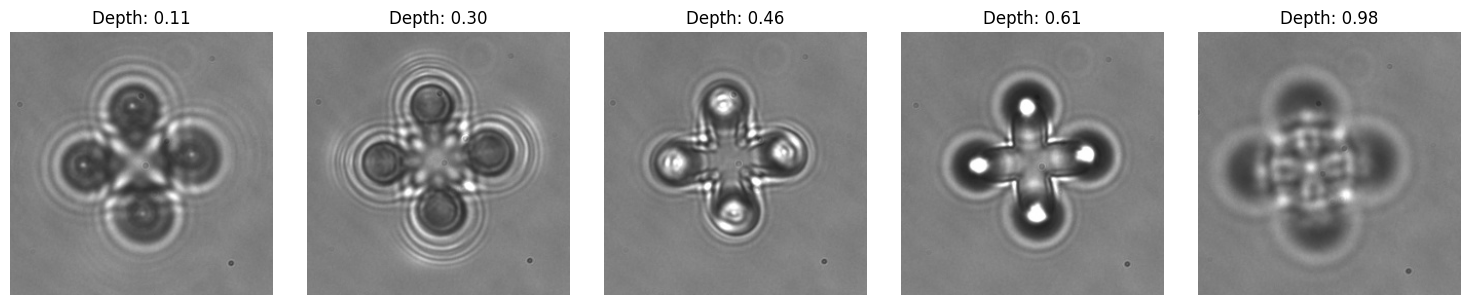

In [ ]:
# Function to visualise images at varying depth levels
def visualise_depth_samples(labels, image_dir, depth_levels=5):
    """
    Visualises images for varying levels of depth from the dataset.

    :param labels: DataFrame containing the labels
    :param image_dir: Directory where image files are stored
    :param depth_levels: Number of depth levels to sample
    """
    # Divide the depth range into bins and select an image for each bin
    depth_bins = pd.cut(labels['Depth'], bins=depth_levels, labels=False)
    samples = labels.groupby(depth_bins).first()  # Take the first image from each depth bin

    plt.figure(figsize=(15, 3))
    for i, (index, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(image_dir, row['FileName'])
        if os.path.exists(img_path):  # Check if the image file exists
            img = Image.open(img_path)
            plt.subplot(1, depth_levels, i + 1)
            plt.imshow(img)
            plt.title(f"Depth: {row['Depth']:.2f}")
            plt.axis('off')
        else:
            print(f"Image file not found: {img_path}")

    plt.tight_layout()
    plt.show()

# Visualise the data samples
visualise_depth_samples(labels, image_dir, depth_levels=5)

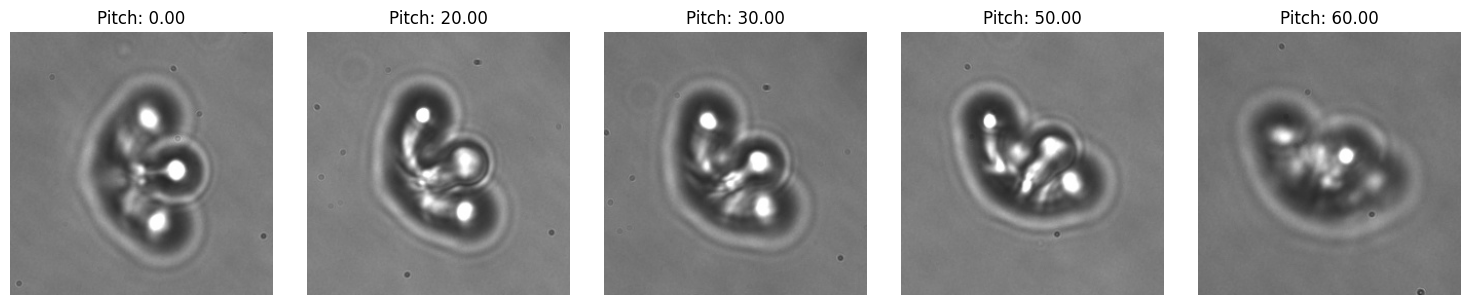

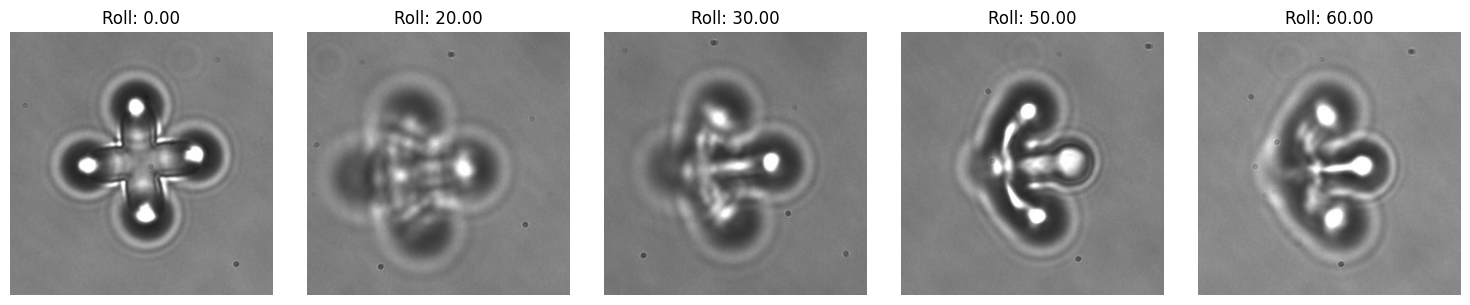

In [ ]:
# Function to visualise images for varying Pitch while Roll is constant
def visualise_pitch_samples(labels, image_dir, roll_value, pitch_levels=5):
    """
    Visualises images for varying Pitch values while keeping Roll constant.

    :param labels: DataFrame containing the labels
    :param image_dir: Directory where image files are stored
    :param roll_value: The Roll value to filter the data
    :param pitch_levels: Number of Pitch levels to sample
    """
    # Filter the dataset for the given Roll value
    filtered_labels = labels[labels['Roll'] == roll_value]

    # Divide the Pitch range into bins and select a sample from each bin
    pitch_bins = pd.cut(filtered_labels['Pitch'], bins=pitch_levels, labels=False)
    samples = filtered_labels.groupby(pitch_bins).first()  # Take the first image from each bin

    plt.figure(figsize=(15, 3))
    for i, (index, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(image_dir, row['FileName'])
        if os.path.exists(img_path):  # Check if the image file exists
            img = Image.open(img_path)
            plt.subplot(1, pitch_levels, i + 1)
            plt.imshow(img)
            plt.title(f"Pitch: {row['Pitch']:.2f}")
            plt.axis('off')
        else:
            print(f"Image file not found: {img_path}")

    plt.tight_layout()
    plt.show()

# Function to visualise images for varying Roll values while Pitch is constant
def visualise_roll_samples(labels, image_dir, pitch_value, roll_levels=5):
    """
    Visualises images for varying Roll values while keeping Pitch constant.

    :param labels: DataFrame containing the labels
    :param image_dir: Directory where image files are stored
    :param pitch_value: The Pitch value to filter the data
    :param roll_levels: Number of Roll levels to sample
    """
    # Filter the dataset for the given Pitch value
    filtered_labels = labels[labels['Pitch'] == pitch_value]

    # Divide the Roll range into bins and select a sample from each bin
    roll_bins = pd.cut(filtered_labels['Roll'], bins=roll_levels, labels=False)
    samples = filtered_labels.groupby(roll_bins).first()  # Take the first image from each bin

    plt.figure(figsize=(15, 3))
    for i, (index, row) in enumerate(samples.iterrows()):
        img_path = os.path.join(image_dir, row['FileName'])
        if os.path.exists(img_path):  # Check if the image file exists
            img = Image.open(img_path)
            plt.subplot(1, roll_levels, i + 1)
            plt.imshow(img)
            plt.title(f"Roll: {row['Roll']:.2f}")
            plt.axis('off')
        else:
            print(f"Image file not found: {img_path}")

    plt.tight_layout()
    plt.show()

roll_value = 70
visualise_pitch_samples(labels, image_dir, roll_value, pitch_levels=5)

pitch_value = 0
visualise_roll_samples(labels, image_dir, pitch_value, roll_levels=5)

# Data Preprocessing

### Data Label Loading and Preprocessing
The label data was loaded from `Label.txt` using `pandas`. It included `Filename`, `Pitch`, `Roll`, and `Depth` as columns. A combined `Pose_Class` was created by concatenating the `Pitch` and `Roll` values, enabling stratified splitting while preserving class distribution.

### Dataset Splitting
The dataset was split into three subsets:
- **Training Set**: 60% of the data.
- **Validation Set**: 20% of the data.
- **Test Set**: 20% of the data.

All splits were performed using stratified sampling on the `Pose_Class` column to maintain the balance of pose class distributions.

### Dataset Class Definition
A custom PyTorch dataset class, `MicrobotDataset`, was implemented:
- Inputs include the dataframe, the image directory path, and optional transformations.
- Each data sample retrieves:
  - Grayscale image converted using `Pillow`.
  - Discretised `Pitch` and `Roll` labels.
  - Continuous `Depth` values converted to PyTorch tensors.

### Mean and Standard Deviation Computation
To standardise the grayscale image inputs, the mean and standard deviation of pixel values were computed exclusively on the training dataset:
- **Mean**: Average pixel intensity across all images.
- **Standard Deviation**: Variability of pixel intensities.

### Data Augmentation and Transformation
Two distinct transformation pipelines were defined:
- **Training Transformations**:
  - Resize to `(128, 128)`.
  - Random sharpness adjustments.
  - Brightness and contrast variations using `ColorJitter`.
  - Conversion to tensor and normalization using the computed mean and standard deviation.
- **Validation and Test Transformations**:
  - Resize to `(128, 128)`.
  - Conversion to tensor and normalization, without augmentation.

### Dataset Loading
PyTorch DataLoaders were configured for efficient data handling during model training and evaluation:
- **Batch Size**: 16.
- **Shuffling**: Enabled for training to enhance generalization.

### Class Distribution Verification
The pose class distributions for the training, validation, and test datasets were verified to confirm balanced stratification.


In [ ]:
# Paths
image_dir = './Database/Image'
label_file_path = './Database/Label.txt'

# Load label file
columns = ['Filename', 'Pitch', 'Roll', 'Depth']
df = pd.read_csv(label_file_path, sep=' ', names=columns)

# Create combined pose class
df['Pose_Class'] = df['Pitch'].astype(str) + '_' + df['Roll'].astype(str)

# Stratified split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(df, test_size=0.2, stratify=df['Pose_Class'], random_state=42)

# Stratified split: 60% train, 20% val
train_df, val_df = train_test_split(train_val_df, test_size=0.25, stratify=train_val_df['Pose_Class'], random_state=42)

print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(val_df)}")
print(f"Test size: {len(test_df)}")

# Dataset class
class MicrobotDataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['Filename'])
        image = Image.open(img_path).convert('L')  # Convert to grayscale

        if self.transform:
            image = self.transform(image)

        pitch_label = int(row['Pitch'] // 10)
        roll_label = int(row['Roll'] // 10)
        depth = torch.tensor(row['Depth'], dtype=torch.float)

        return image, pitch_label, roll_label, depth

def compute_mean_std(image_dir, df):
    pixel_values = []
    for idx in range(len(df)):
        img_path = os.path.join(image_dir, df.iloc[idx]['Filename'])
        image = Image.open(img_path).convert('L')  # Convert to grayscale
        pixel_values.append(np.array(image).flatten())  # Flatten to 1D array

    # Concatenate all pixel values
    pixel_values = np.concatenate(pixel_values).astype(np.float32)
    mean = np.mean(pixel_values) / 255.0  # Normalize to [0, 1]
    std = np.std(pixel_values) / 255.0    # Normalize to [0, 1]
    return mean, std

# Compute mean and std only on the training dataset
train_mean, train_std = compute_mean_std(image_dir, train_df)
print(f"Training dataset mean: {train_mean}, std: {train_std}")

# Transform for training dataset with augmentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomAdjustSharpness(1.6, p=0.5), # Adjust sharpness
    transforms.ColorJitter(brightness=0.15, contrast=0.2),  # Random brightness and contrast
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])  # Normalize with computed mean and std
])

# Transform for validation and test datasets
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[train_mean], std=[train_std])  # Grayscale uses single-channel mean and std
])

# Create datasets and DataLoaders
train_dataset = MicrobotDataset(train_df, image_dir, transform=train_transform)
val_dataset = MicrobotDataset(val_df, image_dir, transform=val_test_transform)
test_dataset = MicrobotDataset(test_df, image_dir, transform=val_test_transform)

train_loader_gray = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_gray = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader_gray = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Verify class distribution
def check_class_distribution(df, split_name):
    print(f"\n{split_name} Pose Class Distribution:")
    print(df['Pose_Class'].value_counts(normalize=True))

check_class_distribution(train_df, "Train")
check_class_distribution(val_df, "Validation")
check_class_distribution(test_df, "Test")


Train size: 1209
Validation size: 403
Test size: 404
Training dataset mean: 0.47149631275850185, std: 0.09167050380332797

Train Pose Class Distribution:
Pose_Class
20_20    0.028122
10_60    0.028122
60_70    0.028122
20_60    0.028122
30_50    0.028122
50_70    0.028122
40_70    0.028122
30_60    0.028122
50_60    0.028122
10_40    0.028122
0_20     0.028122
30_30    0.028122
0_30     0.028122
0_0      0.028122
20_30    0.028122
0_10     0.028122
0_40     0.028122
0_50     0.028122
10_30    0.028122
50_50    0.028122
60_60    0.028122
10_20    0.027295
40_50    0.027295
20_40    0.027295
0_70     0.027295
10_70    0.027295
10_50    0.027295
10_10    0.027295
20_50    0.027295
30_70    0.027295
40_60    0.027295
30_40    0.027295
70_70    0.027295
20_70    0.027295
0_60     0.027295
40_40    0.027295
Name: proportion, dtype: float64

Validation Pose Class Distribution:
Pose_Class
70_70    0.029777
20_40    0.029777
10_10    0.029777
10_50    0.029777
40_40    0.029777
40_50    0.02977

### Dataset Class Definition
To accommodate models like ResNet and MobileNet, which require 3-channel RGB inputs, the dataset class was updated:
- The images were converted to RGB format using the `Pillow` library.
- The data sample now includes:
  - An RGB image.
  - Discretized `Pitch` and `Roll` labels.
  - A continuous `Depth` value converted to a PyTorch tensor.

### Function to Compute Mean and Standard Deviation
To normalize RGB images, the mean and standard deviation were computed for each channel across the training dataset:
- **Mean**: Average pixel intensity for each channel (R, G, B).
- **Standard Deviation**: Variability of pixel intensities for each channel.

### Data Augmentation and Transformation
Two transformation pipelines were defined for the RGB images:
- **Training Transformations**:
  - Resize to `(128, 128)`.
  - Random sharpness adjustments.
  - Brightness and contrast variations using `ColorJitter`.
  - Conversion to tensor and normalization using the computed mean and standard deviation for the three channels.
- **Validation and Test Transformations**:
  - Resize to `(128, 128)`.
  - Conversion to tensor and normalization using the computed mean and standard deviation for the three channels.

### Dataset Loading
PyTorch DataLoaders were configured for RGB inputs:
- **Batch Size**: 16.
- **Shuffling**: Enabled for training to enhance generalization.

In [ ]:
# Dataset class
class MicrobotDataset(torch.utils.data.Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row['Filename'])
        image = Image.open(img_path).convert('RGB')  # Ensure RGB format

        if self.transform:
            image = self.transform(image)

        pitch_label = int(row['Pitch'] // 10)
        roll_label = int(row['Roll'] // 10)
        depth = torch.tensor(row['Depth'], dtype=torch.float)

        return image, pitch_label, roll_label, depth

# Function to compute mean and standard deviation
def compute_mean_std(image_dir, df):
    means = []
    stds = []
    for idx in range(len(df)):
        img_path = os.path.join(image_dir, df.iloc[idx]['Filename'])
        image = Image.open(img_path).convert('RGB')  # Ensure RGB
        image_array = np.array(image).astype(np.float32) / 255.0  # Normalize to [0, 1]

        # Calculate mean and std for each channel
        means.append(np.mean(image_array, axis=(0, 1)))  # Mean per channel
        stds.append(np.std(image_array, axis=(0, 1)))    # Std per channel

    # Average means and stds across all images
    mean = np.mean(means, axis=0)
    std = np.mean(stds, axis=0)
    return mean, std


# Compute mean and std only on the training dataset
train_mean, train_std = compute_mean_std(image_dir, train_df)
print(f"Training dataset mean: {train_mean}, std: {train_std}")

# Transform for training dataset with augmentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomAdjustSharpness(1.6, p=0.5),  # Adjust sharpness
    transforms.ColorJitter(brightness=0.15, contrast=0.2),  # Random brightness and contrast
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())  # Use 3-channel mean and std
])

# Transform for validation and test datasets
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=train_mean.tolist(), std=train_std.tolist())  # Use 3-channel mean and std
])

# Create datasets and DataLoaders
train_dataset = MicrobotDataset(train_df, image_dir, transform=train_transform)
val_dataset = MicrobotDataset(val_df, image_dir, transform=val_test_transform)
test_dataset = MicrobotDataset(test_df, image_dir, transform=val_test_transform)

train_loader_rgb = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader_rgb = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader_rgb = DataLoader(test_dataset, batch_size=16, shuffle=False)

# Verify class distribution
def check_class_distribution(df, split_name):
    print(f"\n{split_name} Pose Class Distribution:")
    print(df['Pose_Class'].value_counts(normalize=True))

check_class_distribution(train_df, "Train")
check_class_distribution(val_df, "Validation")
check_class_distribution(test_df, "Test")


Training dataset mean: [0.47154418 0.47154418 0.47154418], std: [0.08954164 0.08954164 0.08954164]

Train Pose Class Distribution:
Pose_Class
20_20    0.028122
10_60    0.028122
60_70    0.028122
20_60    0.028122
30_50    0.028122
50_70    0.028122
40_70    0.028122
30_60    0.028122
50_60    0.028122
10_40    0.028122
0_20     0.028122
30_30    0.028122
0_30     0.028122
0_0      0.028122
20_30    0.028122
0_10     0.028122
0_40     0.028122
0_50     0.028122
10_30    0.028122
50_50    0.028122
60_60    0.028122
10_20    0.027295
40_50    0.027295
20_40    0.027295
0_70     0.027295
10_70    0.027295
10_50    0.027295
10_10    0.027295
20_50    0.027295
30_70    0.027295
40_60    0.027295
30_40    0.027295
70_70    0.027295
20_70    0.027295
0_60     0.027295
40_40    0.027295
Name: proportion, dtype: float64

Validation Pose Class Distribution:
Pose_Class
70_70    0.029777
20_40    0.029777
10_10    0.029777
10_50    0.029777
40_40    0.029777
40_50    0.029777
10_20    0.029777
30_

# Creating Model Architecture - PoseDepthNet (Model 1)

### Overview
The **PoseDepthNet** model was designed as a unified architecture to simultaneously perform pose classification (for pitch and roll angles) and depth estimation. It features shared convolutional layers for feature extraction, followed by separate heads for classification and regression tasks.

### Model Details
1. **Input**:
   - The model accepts grayscale images of size `(128, 128)` as input, with a single-channel depth.

2. **Shared Feature Extraction Layers**:
   - Three convolutional layers, each followed by ReLU activations and max pooling operations, form the shared feature extraction backbone.
   - The shared layers extract robust, high-level features common to both classification and regression tasks.

3. **Task-Specific Heads**:
   - **Pitch Classification Head**:
     - Fully connected layers for classifying pitch into 8 discrete classes.
   - **Roll Classification Head**:
     - Fully connected layers for classifying roll into 8 discrete classes.
   - **Depth Regression Head**:
     - Fully connected layers for predicting depth as a continuous value.

4. **Dropout**:
   - A dropout layer with a probability of 10% (`0.10`) was included in each head to prevent overfitting.

5. **Dynamic Flattened Feature Size**:
   - The size of the flattened feature vector was dynamically computed during initialization using a dummy input, ensuring flexibility for different input sizes.

### Forward Pass
1. The input image is passed through the shared convolutional layers to extract high-level features.
2. These features are flattened and fed into:
   - The **pitch classification head** for predicting pitch.
   - The **roll classification head** for predicting roll.
   - The **depth regression head** for predicting depth.
3. The model outputs three predictions:
   - `pitch`: Tensor of shape `[batch_size, 8]`.
   - `roll`: Tensor of shape `[batch_size, 8]`.
   - `depth`: Tensor of shape `[batch_size, 1]`.

In [ ]:
class PoseDepthNet(nn.Module):
    def __init__(self, dropout_prob=0.10, input_size=(128, 128)):
        super(PoseDepthNet, self).__init__()

        # Shared feature extraction layers
        self.shared_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # Dynamically compute the size of flattened features
        with torch.no_grad():
            dummy_input = torch.zeros(1, 1, *input_size)  # Grayscale input
            flattened_size = self.shared_layers(dummy_input).view(1, -1).shape[1]

        # Classification head for pitch and roll (8 classes each)
        self.fc_pitch = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 8)
        )
        self.fc_roll = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 8)
        )

        # Regression head for depth estimation
        self.fc_depth = nn.Sequential(
            nn.Linear(flattened_size, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.shared_layers(x).view(x.size(0), -1) # Flatten feature maps
        pitch = self.fc_pitch(features)
        roll = self.fc_roll(features)
        depth = self.fc_depth(features)
        return pitch, roll, depth



# Resnet-18 (Model 2)

### Overview
The **PoseDepthResNet18** model leverages a pretrained ResNet-18 backbone to perform multitask learning for pose classification (pitch and roll) and depth estimation. It uses the powerful feature extraction capabilities of ResNet-18, pretrained on ImageNet, while incorporating custom heads for each task.

### Model Details
1. **Base Architecture**:
   - ResNet-18, a widely used convolutional neural network, was employed as the backbone for feature extraction.
   - The pretrained model ensures efficient and effective initialization, leveraging transfer learning from ImageNet.

2. **Custom Modifications**:
   - The fully connected classification layer (`fc`) of ResNet-18 was replaced with an identity layer, allowing the integration of task-specific heads.
   - Features extracted from the ResNet backbone were passed to three separate heads for the tasks of pitch classification, roll classification, and depth regression.

3. **Task-Specific Heads**:
   - **Pitch Classification Head**:
     - Predicts pitch angle from 8 discrete classes using two fully connected layers.
   - **Roll Classification Head**:
     - Predicts roll angle from 8 discrete classes using two fully connected layers.
   - **Depth Regression Head**:
     - Outputs depth as a continuous value using two fully connected layers.

4. **Dropout**:
   - A dropout layer with a probability of 10% (`0.10`) was included in each head to reduce overfitting.

### Forward Pass
1. The input image is passed through the ResNet-18 backbone to extract high-level features.
2. The extracted features are routed to:
   - The **pitch classification head** for predicting pitch logits.
   - The **roll classification head** for predicting roll logits.
   - The **depth regression head** for predicting depth as a continuous value.
3. The model outputs three predictions:
   - `pitch_logits`: Tensor of shape `[batch_size, num_pitch_classes]`.
   - `roll_logits`: Tensor of shape `[batch_size, num_roll_classes]`.
   - `depth_output`: Tensor of shape `[batch_size, 1]`.


In [ ]:
class PoseDepthResNet18(nn.Module):
    """
    A ResNet-18-based model with three heads:
        - Pitch classification (8 classes)
        - Roll classification (8 classes)
        - Depth regression (single output)
    """
    def __init__(self, num_pitch_classes=8, num_roll_classes=8, dropout_prob=0.1):
        super(PoseDepthResNet18, self).__init__()

        # Load a pretrained ResNet-18 from torchvision (trained on ImageNet)
        self.resnet = models.resnet18(pretrained=True)

        # Replace the final fully connected layer with an identity so we can attach custom classification/regression heads
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()

        # 3) Define pitch classification head
        self.pitch_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, num_pitch_classes)
        )

        # 4) Define roll classification head
        self.roll_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, num_roll_classes)
        )

        # 5) Define depth regression head
        self.depth_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        # Pass input through the ResNet backbone
        features = self.resnet(x)  # shape: (batch_size, in_features)

        # Pass the extracted features to each head
        pitch_logits = self.pitch_head(features)
        roll_logits = self.roll_head(features)
        depth_output = self.depth_head(features)

        return pitch_logits, roll_logits, depth_output


# MobileNetV3 (Model 3)

### Overview
The **PoseDepthMobileNetV3** model utilizes a pretrained MobileNetV3-Small architecture as its backbone for multitask learning. This lightweight model is particularly suited for applications requiring efficient inference on devices with limited computational resources. The model is tailored for pose classification (pitch and roll) and depth estimation tasks.

### Model Details
1. **Base Architecture**:
   - MobileNetV3-Small, a compact convolutional neural network, was selected as the backbone for feature extraction.
   - The pretrained weights (`IMAGENET1K_V1`) initialize the model, leveraging transfer learning from ImageNet.

2. **Custom Modifications**:
   - The `classifier` layer of MobileNetV3-Small was replaced, preserving the feature extraction layers while modifying the classification head:
     - The final `Linear(1024 → 1000)` layer was replaced with an identity layer to retain a feature vector of size 1024.
     - The resulting backbone outputs feature embeddings of shape `[batch_size, 1024]`.

3. **Task-Specific Heads**:
   - **Pitch Classification Head**:
     - Predicts pitch angle from 8 discrete classes using two fully connected layers.
   - **Roll Classification Head**:
     - Predicts roll angle from 8 discrete classes using two fully connected layers.
   - **Depth Regression Head**:
     - Outputs depth as a continuous value using two fully connected layers.

4. **Dropout**:
   - A dropout layer with a probability of 10% (`0.10`) was included in each head to mitigate overfitting.

### Forward Pass
1. The input image is passed through the MobileNetV3-Small backbone to extract high-level features.
2. The extracted features are routed to:
   - The **pitch classification head** for predicting pitch logits.
   - The **roll classification head** for predicting roll logits.
   - The **depth regression head** for predicting depth as a continuous value.
3. The model outputs three predictions:
   - `pitch_logits`: Tensor of shape `[batch_size, num_pitch_classes]`.
   - `roll_logits`: Tensor of shape `[batch_size, num_roll_classes]`.
   - `depth_output`: Tensor of shape `[batch_size, 1]`.

In [ ]:
class PoseDepthMobileNetV3(nn.Module):
    def __init__(self, num_pitch_classes=8, num_roll_classes=8, dropout_prob=0.1):
        super().__init__()

        self.mobilenet = models.mobilenet_v3_small(
            weights=models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        # Current classifier is a Sequential of length 4:
        #  [0] Linear(576 -> 1024)
        #  [1] Hardswish
        #  [2] Dropout(0.2)
        #  [3] Linear(1024 -> 1000)
        #
        # Remove only the final layer so we end up with 1024 features:
        self.mobilenet.classifier = nn.Sequential(
            self.mobilenet.classifier[0],  # Linear(576 -> 1024)
            self.mobilenet.classifier[1],  # Hardswish
            self.mobilenet.classifier[2],  # Dropout(0.2)
            nn.Identity()                  # Instead of linear(1024->1000)
        )

        # Now the output of self.mobilenet is [batch_size, 1024].
        in_features = 1024

        self.pitch_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, num_pitch_classes)
        )

        self.roll_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, num_roll_classes)
        )

        self.depth_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        features = self.mobilenet(x)  # [batch_size, 1024]
        pitch_logits = self.pitch_head(features)
        roll_logits = self.roll_head(features)
        depth_output = self.depth_head(features)
        return pitch_logits, roll_logits, depth_output


# Hyperparameter Tuning - Grid Search

### Objective
The grid search aims to identify the optimal weights for the combined loss function components: pitch classification, roll classification, and depth regression. The goal is to balance the contributions of these tasks to the overall loss, ensuring robust multitask learning.

### Loss Function
The combined loss function integrates three tasks:
- Pitch classification weighted by `pitch_weight`.
- Roll classification weighted by `roll_weight`.
- Depth regression weighted by `depth_weight`.

The total loss is calculated as a weighted sum of these components.

### Metrics
The model's performance is evaluated using:
1. **Classification Accuracy**:
   - `pitch_accuracy` for pitch classification.
   - `roll_accuracy` for roll classification.
2. **Depth Estimation RMSE**:
   - Root Mean Squared Error (RMSE) for depth regression.
3. **Composite Metric**:
   - Combines classification accuracy and RMSE to assess overall performance. Lower composite scores indicate better performance.

### Search Space
The search grid includes:
- Shared weight for pitch and roll classification: `[0.001, 0.01, 0.1, 1, 5]`.
- Weight for depth regression: `[0.1, 1, 10, 50]`.

### Implementation
For each combination of weights:
1. The model is trained with early stopping to prevent overfitting.
2. Validation loss is monitored during training to select the best-performing model.
3. The composite metric is calculated on validation data to rank the hyperparameter combinations.

### Key Results
The grid search outputs:
- **Optimal Weights**: Best values for `pitch_weight`, `roll_weight`, and `depth_weight`.
- **Best Composite Score**: The lowest composite score achieved, indicating the best balance between classification and regression tasks.


In [ ]:
def combined_loss(pitch_pred, pitch_true, roll_pred, roll_true, depth_pred, depth_true,
                  pitch_weight=1.0, roll_weight=1.0, depth_weight=2.0):
    """
    Combined loss function with adjustable weights for each task.

    Returns:
    - Combined weighted loss.
    """
    loss_pitch = criterion_pitch(pitch_pred, pitch_true)
    loss_roll = criterion_roll(roll_pred, roll_true)
    loss_depth = criterion_depth(depth_pred.squeeze(), depth_true)

    # Weighted sum of losses
    total_loss = pitch_weight * loss_pitch + roll_weight * loss_roll + depth_weight * loss_depth

    return total_loss

In [ ]:
def evaluate_model_metrics(model, loader, device):
    model.eval()

    all_pitch_preds, all_roll_preds, all_depth_preds = [], [], []
    all_pitch_labels, all_roll_labels, all_depth_labels = [], [], []

    with torch.no_grad():
        for images, pitch_labels, roll_labels, depths in loader:
            images = images.to(device)
            pitch_labels = pitch_labels.to(device)
            roll_labels = roll_labels.to(device)
            depths = depths.to(device)

            # Forward pass
            pitch_pred, roll_pred, depth_pred = model(images)

            # Classification predictions
            pitch_pred_classes = torch.argmax(pitch_pred, dim=1).cpu().numpy()
            roll_pred_classes = torch.argmax(roll_pred, dim=1).cpu().numpy()
            pitch_labels = pitch_labels.cpu().numpy()
            roll_labels = roll_labels.cpu().numpy()

            # Regression predictions
            depth_pred = depth_pred.squeeze().cpu().numpy()
            depths = depths.cpu().numpy()

            # Collect results
            all_pitch_preds.extend(pitch_pred_classes)
            all_roll_preds.extend(roll_pred_classes)
            all_depth_preds.extend(depth_pred)
            all_pitch_labels.extend(pitch_labels)
            all_roll_labels.extend(roll_labels)
            all_depth_labels.extend(depths)

    # Classification Metrics
    pitch_accuracy = accuracy_score(all_pitch_labels, all_pitch_preds)
    roll_accuracy = accuracy_score(all_roll_labels, all_roll_preds)

    # Depth Estimation Metrics
    rmse = np.sqrt(mean_squared_error(all_depth_labels, all_depth_preds))

    return pitch_accuracy, roll_accuracy, rmse


In [ ]:
model = PoseDepthNet()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

PoseDepthNet(
  (shared_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_pitch): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
  (fc_roll): Sequential(
    (0): Linear(in_features=32768, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=128, out_features=8, bias=True)
  )
  (fc_dep

In [ ]:
# Define the search grid for multipliers
shared_pitch_roll_weights = [0.001, 0.01, 0.1, 1, 5]
depth_weights = [0.1, 1, 10, 50]

# Global variables to store the overall best combination and its score
global_best_combination = None
global_best_score = float('inf')  # Lower is better since the score includes (1-accuracy) and RMSE

# Loop through all combinations of multipliers
for shared_weight in shared_pitch_roll_weights:
    for depth_weight in depth_weights:
        print(f"Testing multipliers: pitch_roll={shared_weight}, depth={depth_weight}")

        # Initialize the model, criterion, and optimizer
        model = PoseDepthNet().to(device)
        criterion_pitch = nn.CrossEntropyLoss()
        criterion_roll = nn.CrossEntropyLoss()
        criterion_depth = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # Number of epochs and early stopping patience
        num_epochs = 10
        early_stopping_patience = 3
        patience_counter = 0

        # Reset the best validation loss for this hyperparameter configuration
        best_val_loss = float('inf')

        # Training loop
        for epoch in range(num_epochs):
            model.train()
            train_loss = 0

            for images, pitch_labels, roll_labels, depths in train_loader_gray:
                images = images.to(device)
                pitch_labels = pitch_labels.to(device)
                roll_labels = roll_labels.to(device)
                depths = depths.to(device)

                # Zero gradients
                optimizer.zero_grad()

                # Forward pass
                pitch_pred, roll_pred, depth_pred = model(images)

                # Compute combined loss
                loss = (
                    shared_weight * criterion_pitch(pitch_pred, pitch_labels) +
                    shared_weight * criterion_roll(roll_pred, roll_labels) +
                    depth_weight * criterion_depth(depth_pred.squeeze(), depths)
                )

                # Backward pass and optimization
                loss.backward()
                optimizer.step()
                train_loss += loss.item()

            # Validation loop for early stopping
            model.eval()
            val_loss = 0
            with torch.no_grad():
                for images, pitch_labels, roll_labels, depths in val_loader_gray:
                    images = images.to(device)
                    pitch_labels = pitch_labels.to(device)
                    roll_labels = roll_labels.to(device)
                    depths = depths.to(device)

                    # Forward pass
                    pitch_pred, roll_pred, depth_pred = model(images)

                    # Compute combined loss
                    loss = (
                        shared_weight * criterion_pitch(pitch_pred, pitch_labels) +
                        shared_weight * criterion_roll(roll_pred, roll_labels) +
                        depth_weight * criterion_depth(depth_pred.squeeze(), depths)
                    )
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader_gray)

            print(f"Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_val_loss:.4f}")

            # Early stopping logic
            if avg_val_loss < best_val_loss:
                best_val_loss = avg_val_loss
                patience_counter = 0
            else:
                patience_counter += 1

            if patience_counter >= early_stopping_patience:
                print("Early stopping triggered.")
                break

        # Evaluate the model metrics
        pitch_accuracy, roll_accuracy, rmse = evaluate_model_metrics(model, val_loader_gray, device)
        composite_score = ((1 - pitch_accuracy) + (1 - roll_accuracy)) / 2 + rmse / 2

        print(f"Finished multipliers: pitch_roll={shared_weight}, depth={depth_weight}, "
              f"Composite Score: {composite_score:.4f}, "
              f"Pitch Accuracy: {pitch_accuracy:.4f}, Roll Accuracy: {roll_accuracy:.4f}, RMSE: {rmse:.4f}")

        # Update global best combination based on composite score
        if composite_score < global_best_score:
            global_best_score = composite_score
            global_best_combination = (shared_weight, depth_weight)

# Print the global best combination of multipliers
print(f"Best multipliers: pitch_roll={global_best_combination[0]}, depth={global_best_combination[1]}")
print(f"Best Composite Score: {global_best_score:.4f}")


Testing multipliers: pitch_roll=0.001, depth=0.1
Epoch [1/10], Validation Loss: 0.0049
Epoch [2/10], Validation Loss: 0.0030
Epoch [3/10], Validation Loss: 0.0021
Epoch [4/10], Validation Loss: 0.0024
Epoch [5/10], Validation Loss: 0.0020
Epoch [6/10], Validation Loss: 0.0012
Epoch [7/10], Validation Loss: 0.0015
Epoch [8/10], Validation Loss: 0.0009
Epoch [9/10], Validation Loss: 0.0018
Epoch [10/10], Validation Loss: 0.0014
Finished multipliers: pitch_roll=0.001, depth=0.1, Composite Score: 0.0871, Pitch Accuracy: 0.9801, Roll Accuracy: 0.9504, RMSE: 0.1046
Testing multipliers: pitch_roll=0.001, depth=1
Epoch [1/10], Validation Loss: 0.0391
Epoch [2/10], Validation Loss: 0.0245
Epoch [3/10], Validation Loss: 0.0135
Epoch [4/10], Validation Loss: 0.0129
Epoch [5/10], Validation Loss: 0.0130
Epoch [6/10], Validation Loss: 0.0119
Epoch [7/10], Validation Loss: 0.0254
Epoch [8/10], Validation Loss: 0.0132
Epoch [9/10], Validation Loss: 0.0112
Epoch [10/10], Validation Loss: 0.0053
Finish

In [ ]:
pitch_scaler, roll_scaler = global_best_combination[0], global_best_combination[0]
depth_scaler =  global_best_combination[1]

# Model Training - PoseDepthNet

### Objective
To train the **PoseDepthNet** model using a robust training pipeline that incorporates:
1. Early stopping to prevent overfitting.
2. A learning rate scheduler to dynamically adjust the learning rate based on validation loss.

### Training Process
1. **Initialization**:
   - The model was initialized on the appropriate device (CPU/GPU).
   - Separate loss functions for pitch, roll, and depth tasks were defined:
     - `CrossEntropyLoss` for pitch and roll classification.
     - `MSELoss` for depth regression.
   - The optimizer (`Adam`) was initialized with a learning rate of 0.001.

2. **Learning Rate Scheduler**:
   - A `ReduceLROnPlateau` scheduler was employed to reduce the learning rate by a factor of 0.1 if validation loss did not improve for two consecutive epochs.

3. **Early Stopping**:
   - Training was halted early if validation loss failed to improve for five consecutive epochs, allowing more patience due to the adaptive learning rate.

4. **Loss Calculation**:
   - A **combined loss function** weighted pitch, roll, and depth losses based on the best weights identified during grid search.

5. **Epoch Workflow**:
   - **Training Phase**:
     - Input images were passed through the model.
     - Loss was calculated using the combined loss function.
     - Backpropagation and parameter updates were performed.
   - **Validation Phase**:
     - The model's performance was evaluated on the validation set.
     - Loss metrics were recorded for pitch, roll, and depth.

6. **Model Saving**:
   - The model with the best validation loss was saved to a file (`best_pose_depth_model.pth`).

### Key Features
- **Logging**:
  - Training and validation losses were logged for each epoch, including task-specific losses for pitch, roll, and depth.
- **Dynamic Learning Rate**:
  - The scheduler adjusted the learning rate when validation loss plateaued, allowing the model to explore smaller steps.
- **Checkpointing**:
  - The best-performing model was saved to ensure that training progress was preserved.

### Results
- **Performance Metrics**:
  - Training and validation losses were reported for each epoch.
  - The best model was identified based on validation loss.


In [ ]:
# Initialize the model, loss functions, optimizer, and scheduler
model = PoseDepthNet().to(device)
criterion_pitch = nn.CrossEntropyLoss()
criterion_roll = nn.CrossEntropyLoss()
criterion_depth = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Learning rate scheduler: ReduceLROnPlateau
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1, verbose=True)

# Early stopping parameters
early_stopping_patience = 5  # Allow more patience since the scheduler adjusts learning rates
best_val_loss = float('inf')
patience_counter = 0

# Number of epochs
num_epochs = 30

# Training loop with validation
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_loss_pitch = 0
    train_loss_roll = 0
    train_loss_depth = 0

    for images, pitch_labels, roll_labels, depths in train_loader_gray:
        images = images.to(device)
        pitch_labels = pitch_labels.to(device)
        roll_labels = roll_labels.to(device)
        depths = depths.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        pitch_pred, roll_pred, depth_pred = model(images)

        # Compute losses
        loss_pitch = criterion_pitch(pitch_pred, pitch_labels)
        loss_roll = criterion_roll(roll_pred, roll_labels)
        loss_depth = criterion_depth(depth_pred.squeeze(), depths)

        # Combined loss with weights
        loss = combined_loss(pitch_pred, pitch_labels, roll_pred, roll_labels, depth_pred, depths, pitch_scaler, roll_scaler, depth_scaler)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_loss_pitch += loss_pitch.item()
        train_loss_roll += loss_roll.item()
        train_loss_depth += loss_depth.item()

    avg_train_loss = train_loss / len(train_loader_gray)
    avg_train_loss_pitch = train_loss_pitch / len(train_loader_gray)
    avg_train_loss_roll = train_loss_roll / len(train_loader_gray)
    avg_train_loss_depth = train_loss_depth / len(train_loader_gray)

    # Validation phase
    model.eval()

    val_loss = 0
    val_loss_pitch = 0
    val_loss_roll = 0
    val_loss_depth = 0

    with torch.no_grad():
        for images, pitch_labels, roll_labels, depths in val_loader_gray:
            images = images.to(device)
            pitch_labels = pitch_labels.to(device)
            roll_labels = roll_labels.to(device)
            depths = depths.to(device)

            # Forward pass
            pitch_pred, roll_pred, depth_pred = model(images)

            # Compute losses
            loss_pitch = criterion_pitch(pitch_pred, pitch_labels)
            loss_roll = criterion_roll(roll_pred, roll_labels)
            loss_depth = criterion_depth(depth_pred.squeeze(), depths)

            # Combined loss
            loss = combined_loss(pitch_pred, pitch_labels, roll_pred, roll_labels, depth_pred, depths, pitch_scaler, roll_scaler, depth_scaler)

            val_loss += loss.item()
            val_loss_pitch += loss_pitch.item()
            val_loss_roll += loss_roll.item()
            val_loss_depth += loss_depth.item()

    avg_val_loss = val_loss / len(val_loader_gray)
    avg_val_loss_pitch = val_loss_pitch / len(val_loader_gray)
    avg_val_loss_roll = val_loss_roll / len(val_loader_gray)
    avg_val_loss_depth = val_loss_depth / len(val_loader_gray)

    # Print epoch results
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} (Pitch: {avg_train_loss_pitch:.4f}, Roll: {avg_train_loss_roll:.4f}, Depth: {avg_train_loss_depth:.4f})")
    print(f"Validation Loss: {avg_val_loss:.4f} (Pitch: {avg_val_loss_pitch:.4f}, Roll: {avg_val_loss_roll:.4f}, Depth: {avg_val_loss_depth:.4f})")

    # Learning rate scheduler step
    scheduler.step(avg_val_loss)

    # Check for early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_pose_depth_model.pth')
        print("Best model saved.")
    else:
        patience_counter += 1
        print(f"Early stopping counter: {patience_counter}/{early_stopping_patience}")

    if patience_counter >= early_stopping_patience:
        print("Early stopping triggered.")
        break


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch [1/30]
Train Loss: 0.6068 (Pitch: 1.8562, Roll: 1.9429, Depth: 0.5688)
Validation Loss: 0.0724 (Pitch: 1.4342, Roll: 1.6539, Depth: 0.0415)
Best model saved.
Epoch [2/30]
Train Loss: 0.0708 (Pitch: 1.1337, Roll: 1.4686, Depth: 0.0448)
Validation Loss: 0.0387 (Pitch: 0.8658, Roll: 1.1832, Depth: 0.0182)
Best model saved.
Epoch [3/30]
Train Loss: 0.0456 (Pitch: 0.7036, Roll: 1.0018, Depth: 0.0285)
Validation Loss: 0.0309 (Pitch: 0.5429, Roll: 0.8125, Depth: 0.0173)
Best model saved.
Epoch [4/30]
Train Loss: 0.0394 (Pitch: 0.4480, Roll: 0.7408, Depth: 0.0276)
Validation Loss: 0.0199 (Pitch: 0.3408, Roll: 0.6116, Depth: 0.0104)
Best model saved.
Epoch [5/30]
Train Loss: 0.0295 (Pitch: 0.2758, Roll: 0.5284, Depth: 0.0215)
Validation Loss: 0.0168 (Pitch: 0.2317, Roll: 0.4757, Depth: 0.0097)
Best model saved.
Epoch [6/30]
Train Loss: 0.0237 (Pitch: 0.1686, Roll: 0.3845, Depth: 0.0182)
Validation Loss: 0.0169 (Pitch: 0.1547, Roll: 0.3530, Depth: 0.0118)
Early stopping counter: 1/5
Epoch 

# Model Training Resnet-18

### Objective
The **PoseDepthResNet18** model is trained for multitask learning of pitch classification, roll classification, and depth regression. The training process incorporates early stopping and a learning rate scheduler to ensure robust optimization.

### Training Process
1. **Initialization**:
   - The model is initialized with ResNet-18 as the backbone and three task-specific heads.
   - Loss functions for each task are defined:
     - `CrossEntropyLoss` for pitch and roll classification.
     - `MSELoss` for depth regression.
   - The optimizer (`Adam`) is set up with a learning rate of 0.001.

2. **Learning Rate Scheduler**:
   - A `ReduceLROnPlateau` scheduler adjusts the learning rate dynamically. If validation loss does not improve for two consecutive epochs, the learning rate is reduced by a factor of 0.1.

3. **Early Stopping**:
   - The training halts early if validation loss fails to improve for five consecutive epochs, preventing overfitting.

4. **Loss Calculation**:
   - Each task contributes to the total loss, weighted by previously determined scalers:
     \[
     \text{Total Loss} = \text{pitch\_scaler} \times \text{Pitch Loss} + \text{roll\_scaler} \times \text{Roll Loss} + \text{depth\_scaler} \times \text{Depth Loss}
     \]

5. **Epoch Workflow**:
   - **Training Phase**:
     - The model processes input images and computes predictions.
     - Losses are calculated for pitch, roll, and depth tasks.
     - Combined loss is backpropagated, and model parameters are updated.
   - **Validation Phase**:
     - The model's performance is evaluated on the validation dataset.
     - Validation loss is calculated and monitored for early stopping and learning rate adjustments.

6. **Model Saving**:
   - The model with the lowest validation loss is saved to a file (`best_resnet18_pose_depth.pth`).

### Key Features
- **Progress Monitoring**:
  - Training and validation losses are logged at each epoch.
- **Learning Rate Adjustments**:
  - The scheduler ensures efficient learning by reducing the rate when progress stagnates.
- **Checkpointing**:
  - The best-performing model is saved, allowing for recovery and deployment.

### Results
- **Performance Metrics**:
  - Training and validation losses are reported for each epoch.
  - The best model is selected based on validation loss.

In [ ]:
# Create the model
model = PoseDepthResNet18(num_pitch_classes=8, num_roll_classes=8, dropout_prob=0.1)
model = model.to(device)

# Define your existing loss functions
criterion_pitch = nn.CrossEntropyLoss()
criterion_roll = nn.CrossEntropyLoss()
criterion_depth = nn.MSELoss()

# Define your optimiser
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define your learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.1, verbose=True)


num_epochs = 30
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, pitch_labels, roll_labels, depths in train_loader_rgb:
        images = images.to(device)
        pitch_labels = pitch_labels.to(device)
        roll_labels = roll_labels.to(device)
        depths = depths.to(device)

        optimizer.zero_grad()

        # Forward pass through ResNet-18 multi-task model
        pitch_pred, roll_pred, depth_pred = model(images)

        # Calculate each sub-loss
        loss_pitch = criterion_pitch(pitch_pred, pitch_labels)
        loss_roll = criterion_roll(roll_pred, roll_labels)
        loss_depth = criterion_depth(depth_pred.squeeze(), depths)

        # Calculate the combined loss function
        loss = combined_loss(pitch_pred, pitch_labels, roll_pred, roll_labels, depth_pred, depths, pitch_scaler, roll_scaler, depth_scaler)

        # Backprop and optimise
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader_rgb)

    # Validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, pitch_labels, roll_labels, depths in val_loader_rgb:
            images = images.to(device)
            pitch_labels = pitch_labels.to(device)
            roll_labels = roll_labels.to(device)
            depths = depths.to(device)

            pitch_pred, roll_pred, depth_pred = model(images)

            loss_pitch = criterion_pitch(pitch_pred, pitch_labels)
            loss_roll = criterion_roll(roll_pred, roll_labels)
            loss_depth = criterion_depth(depth_pred.squeeze(), depths)

            loss = (pitch_scaler * loss_pitch
                    + roll_scaler * loss_roll
                    + depth_scaler * loss_depth)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader_rgb)

    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Valid Loss: {avg_val_loss:.4f}")

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_resnet18_pose_depth.pth')
        print("  --> Best model saved.")
    else:
        patience_counter += 1
        print(f"  Early stopping counter: {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 173MB/s]


Epoch [1/30]
  Train Loss: 0.1265
  Valid Loss: 0.0470
  --> Best model saved.
Epoch [2/30]
  Train Loss: 0.0500
  Valid Loss: 0.0600
  Early stopping counter: 1/5
Epoch [3/30]
  Train Loss: 0.0415
  Valid Loss: 0.0298
  --> Best model saved.
Epoch [4/30]
  Train Loss: 0.0350
  Valid Loss: 0.0367
  Early stopping counter: 1/5
Epoch [5/30]
  Train Loss: 0.0300
  Valid Loss: 0.0198
  --> Best model saved.
Epoch [6/30]
  Train Loss: 0.0256
  Valid Loss: 0.0141
  --> Best model saved.
Epoch [7/30]
  Train Loss: 0.0226
  Valid Loss: 0.0167
  Early stopping counter: 1/5
Epoch [8/30]
  Train Loss: 0.0201
  Valid Loss: 0.0108
  --> Best model saved.
Epoch [9/30]
  Train Loss: 0.0197
  Valid Loss: 0.0104
  --> Best model saved.
Epoch [10/30]
  Train Loss: 0.0191
  Valid Loss: 0.0182
  Early stopping counter: 1/5
Epoch [11/30]
  Train Loss: 0.0172
  Valid Loss: 0.0104
  --> Best model saved.
Epoch [12/30]
  Train Loss: 0.0160
  Valid Loss: 0.0134
  Early stopping counter: 1/5
Epoch [13/30]
  Tra

# Model Training MobileNetV3

### Objective
To train the **PoseDepthMobileNetV3** model for multitask learning of pitch classification, roll classification, and depth regression. The training pipeline employs early stopping and a learning rate scheduler to optimize model performance while mitigating overfitting.

### Training Process

1. **Initialization**:
   - The model utilizes MobileNetV3-Small as its backbone with three custom heads for pitch classification, roll classification, and depth regression.
   - Loss functions:
     - `CrossEntropyLoss` for pitch and roll classification.
     - `MSELoss` for depth regression.
   - Optimizer: `Adam` with an initial learning rate of 0.001.

2. **Learning Rate Scheduler**:
   - A `ReduceLROnPlateau` scheduler reduces the learning rate by a factor of 0.1 if the validation loss does not improve for two consecutive epochs.

3. **Early Stopping**:
   - Training halts if validation loss fails to improve for five consecutive epochs, preserving computational resources and avoiding overfitting.

4. **Loss Calculation**:
   - A combined loss function integrates pitch, roll, and depth losses with task-specific weights determined during hyperparameter tuning:
     \[
     \text{Total Loss} = \text{pitch\_scaler} \times \text{Pitch Loss} + \text{roll\_scaler} \times \text{Roll Loss} + \text{depth\_scaler} \times \text{Depth Loss}
     \]

5. **Epoch Workflow**:
   - **Training Phase**:
     - The model processes batches of RGB input images and computes task-specific predictions.
     - Losses are computed and combined for backpropagation.
   - **Validation Phase**:
     - The model evaluates its performance on validation data, logging the combined loss.

6. **Model Saving**:
   - The model with the lowest validation loss is saved to a file (`best_mobilenetv3_pose_depth.pth`).

### Features
- **Logging**:
  - Training and validation losses are reported at each epoch.
- **Adaptive Learning Rates**:
  - The learning rate is adjusted based on validation loss trends to improve convergence.
- **Checkpointing**:
  - The best-performing model is saved for deployment or further evaluation.

### Results
- **Performance Metrics**:
  - Training and validation losses demonstrate the model's learning progression.
  - The best model is identified by the lowest validation loss.

In [ ]:
# Create the model
model = PoseDepthMobileNetV3(num_pitch_classes=8, num_roll_classes=8, dropout_prob=0.1)
model.to(device)

# Define your existing loss functions
criterion_pitch = nn.CrossEntropyLoss()
criterion_roll = nn.CrossEntropyLoss()
criterion_depth = nn.MSELoss()

# Define your optimiser
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Define your learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.1,
    verbose=True
)

# Training loop with early stopping
num_epochs = 30
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 5

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for images, pitch_labels, roll_labels, depths in train_loader_rgb:
        images = images.to(device)
        pitch_labels = pitch_labels.to(device)
        roll_labels = roll_labels.to(device)
        depths = depths.to(device)

        optimizer.zero_grad()

        # Forward pass through MobileNetV3 multi-task model
        pitch_pred, roll_pred, depth_pred = model(images)

        # Combined loss
        loss = combined_loss(pitch_pred, pitch_labels, roll_pred, roll_labels, depth_pred, depths, pitch_scaler, roll_scaler, depth_scaler)

        # Backprop and optimise
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader_rgb)

    # Validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, pitch_labels, roll_labels, depths in val_loader_rgb:
            images = images.to(device)
            pitch_labels = pitch_labels.to(device)
            roll_labels = roll_labels.to(device)
            depths = depths.to(device)

            pitch_pred, roll_pred, depth_pred = model(images)

            # Compute combined loss

            loss = combined_loss(pitch_pred, pitch_labels, roll_pred, roll_labels, depth_pred, depths, pitch_scaler, roll_scaler, depth_scaler)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader_rgb)

    # Print progress
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Valid Loss: {avg_val_loss:.4f}")

    # Scheduler step
    scheduler.step(avg_val_loss)

    # Early stopping logic
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), 'best_mobilenetv3_pose_depth.pth')
        print("  --> Best model saved.")
    else:
        patience_counter += 1
        print(f"  Early stopping counter: {patience_counter}/{early_stopping_patience}")
        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered.")
            break

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 80.6MB/s]


Epoch [1/30]
  Train Loss: 0.0848
  Valid Loss: 0.0797
  --> Best model saved.
Epoch [2/30]
  Train Loss: 0.0311
  Valid Loss: 0.0422
  --> Best model saved.
Epoch [3/30]
  Train Loss: 0.0244
  Valid Loss: 0.0468
  Early stopping counter: 1/5
Epoch [4/30]
  Train Loss: 0.0174
  Valid Loss: 0.0098
  --> Best model saved.
Epoch [5/30]
  Train Loss: 0.0119
  Valid Loss: 0.0193
  Early stopping counter: 1/5
Epoch [6/30]
  Train Loss: 0.0117
  Valid Loss: 0.0073
  --> Best model saved.
Epoch [7/30]
  Train Loss: 0.0089
  Valid Loss: 0.0103
  Early stopping counter: 1/5
Epoch [8/30]
  Train Loss: 0.0093
  Valid Loss: 0.0048
  --> Best model saved.
Epoch [9/30]
  Train Loss: 0.0076
  Valid Loss: 0.0062
  Early stopping counter: 1/5
Epoch [10/30]
  Train Loss: 0.0070
  Valid Loss: 0.0049
  Early stopping counter: 2/5
Epoch [11/30]
  Train Loss: 0.0072
  Valid Loss: 0.0041
  --> Best model saved.
Epoch [12/30]
  Train Loss: 0.0065
  Valid Loss: 0.0053
  Early stopping counter: 1/5
Epoch [13/30]

# Model Evaluation

### Objective
Evaluate the trained models (**PoseDepthNet**, **ResNet-18**, and **MobileNetV3**) on the test dataset to assess their performance on pose classification (pitch and roll) and depth regression tasks. Metrics include classification accuracy, mean absolute error (MAE), root mean squared error (RMSE), and R² score.

### Evaluation Workflow
1. **Model Loading**:
   - Load the best-performing weights for each model.
   - Models are evaluated on the test dataset using the saved weights from the training phase.

2. **Test Loss Calculation**:
   - Compute the loss on the test set to provide a final evaluation score.

3. **Classification Metrics**:
   - **Pitch and Roll Accuracy**: Measure the accuracy of pitch and roll predictions.
   - **Classification Reports**: Provide detailed precision, recall, and F1 scores for each class.
   - **Confusion Matrices**: Visualise prediction accuracy for pitch and roll classification.

4. **Depth Regression Metrics**:
   - **MAE**: Mean absolute error for depth predictions.
   - **RMSE**: Root mean squared error for depth predictions.
   - **R² Score**: Measure of goodness-of-fit for depth predictions.

5. **Visualisation**:
   - Plot confusion matrices for pitch and roll classification tasks.
   - Generate a comparative plot of true vs. predicted depth values for a subset of test samples.



In [ ]:
def evaluate_on_test(model, test_loader, device):
    model.eval()
    test_loss = 0

    with torch.no_grad():
        for images, pitch_labels, roll_labels, depths in test_loader:
            images = images.to(device)
            pitch_labels = pitch_labels.to(device)
            roll_labels = roll_labels.to(device)
            depths = depths.to(device)

            pitch_pred, roll_pred, depth_pred = model(images)

            loss_pitch = criterion_pitch(pitch_pred, pitch_labels)
            loss_roll = criterion_roll(roll_pred, roll_labels)
            loss_depth = criterion_depth(depth_pred.squeeze(), depths)

            loss = combined_loss(pitch_pred, pitch_labels, roll_pred, roll_labels, depth_pred, depths, pitch_scaler, roll_scaler, depth_scaler)

            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    print(f"Test Loss: {avg_test_loss:.4f}")


In [ ]:
def evaluate_model(model, loader, device):
    model.eval()

    all_pitch_preds, all_roll_preds, all_depth_preds = [], [], []
    all_pitch_labels, all_roll_labels, all_depth_labels = [], [], []

    with torch.no_grad():
        for images, pitch_labels, roll_labels, depths in loader:
            images = images.to(device)
            pitch_labels = pitch_labels.to(device)
            roll_labels = roll_labels.to(device)
            depths = depths.to(device)

            # Forward pass
            pitch_pred, roll_pred, depth_pred = model(images)

            # Classification predictions
            pitch_pred_classes = torch.argmax(pitch_pred, dim=1).cpu().numpy()
            roll_pred_classes = torch.argmax(roll_pred, dim=1).cpu().numpy()
            pitch_labels = pitch_labels.cpu().numpy()
            roll_labels = roll_labels.cpu().numpy()

            # Regression predictions
            depth_pred = depth_pred.squeeze().cpu().numpy()
            depths = depths.cpu().numpy()

            # Collect results
            all_pitch_preds.extend(pitch_pred_classes)
            all_roll_preds.extend(roll_pred_classes)
            all_depth_preds.extend(depth_pred)
            all_pitch_labels.extend(pitch_labels)
            all_roll_labels.extend(roll_labels)
            all_depth_labels.extend(depths)

    # Classification Metrics
    pitch_accuracy = accuracy_score(all_pitch_labels, all_pitch_preds)
    roll_accuracy = accuracy_score(all_roll_labels, all_roll_preds)

    # Depth Estimation Metrics
    mae = mean_absolute_error(all_depth_labels, all_depth_preds)
    rmse = np.sqrt(mean_squared_error(all_depth_labels, all_depth_preds))
    r2 = r2_score(all_depth_labels, all_depth_preds)

    # Print Metrics
    print("\n=== Pose Classification Metrics ===")
    print(f"Pitch Classification Accuracy: {pitch_accuracy:.4f}")
    print(f"Roll Classification Accuracy: {roll_accuracy:.4f}")

    print("\nPitch Classification Report:")
    print(classification_report(all_pitch_labels, all_pitch_preds))

    print("\nRoll Classification Report:")
    print(classification_report(all_roll_labels, all_roll_preds))

    print("\n=== Depth Estimation Metrics ===")
    print(f"Depth MAE: {mae:.4f}")
    print(f"Depth RMSE: {rmse:.4f}")
    print(f"Depth R² Score: {r2:.4f}")

    # Confusion Matrices
    plot_confusion_matrices(all_pitch_labels, all_pitch_preds, all_roll_labels, all_roll_preds)

    # Depth Prediction Plot
    plot_depth_predictions(all_depth_labels, all_depth_preds)

# Helper function to plot confusion matrices
def plot_confusion_matrices(pitch_labels, pitch_preds, roll_labels, roll_preds):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Pitch Confusion Matrix
    cm_pitch = confusion_matrix(pitch_labels, pitch_preds)
    sns.heatmap(cm_pitch, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Pitch Confusion Matrix')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # Roll Confusion Matrix
    cm_roll = confusion_matrix(roll_labels, roll_preds)
    sns.heatmap(cm_roll, annot=True, fmt='d', cmap='Blues', ax=axes[1])
    axes[1].set_title('Roll Confusion Matrix')
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Actual')

    plt.show()

# Helper function to plot depth predictions
def plot_depth_predictions(y_true, y_pred, num_samples=50):
    plt.figure(figsize=(10, 6))
    plt.plot(y_true[:num_samples], label='True Depth', marker='o')
    plt.plot(y_pred[:num_samples], label='Predicted Depth', marker='x')
    plt.xlabel('Sample Index')
    plt.ylabel('Depth')
    plt.title('Depth Estimation: True vs Predicted')
    plt.legend()
    plt.show()


================Results for PoseDepthNet================


<ipython-input-20-9e114c9a3726>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_pose_depth_model.pth'))


Test Loss: 0.0044

=== Pose Classification Metrics ===
Pitch Classification Accuracy: 0.9901
Roll Classification Accuracy: 0.9851

Pitch Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98        90
           1       0.99      0.99      0.99        78
           2       0.97      1.00      0.99        68
           3       1.00      1.00      1.00        57
           4       1.00      1.00      1.00        45
           5       1.00      1.00      1.00        33
           6       1.00      1.00      1.00        22
           7       1.00      1.00      1.00        11

    accuracy                           0.99       404
   macro avg       0.99      0.99      0.99       404
weighted avg       0.99      0.99      0.99       404


Roll Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.91      0.95        11
           1       1.00      1.00      1.00        

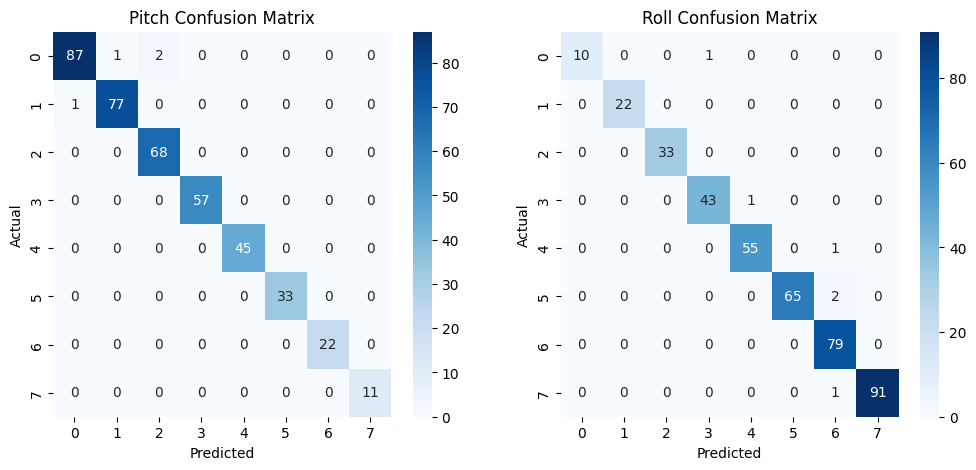

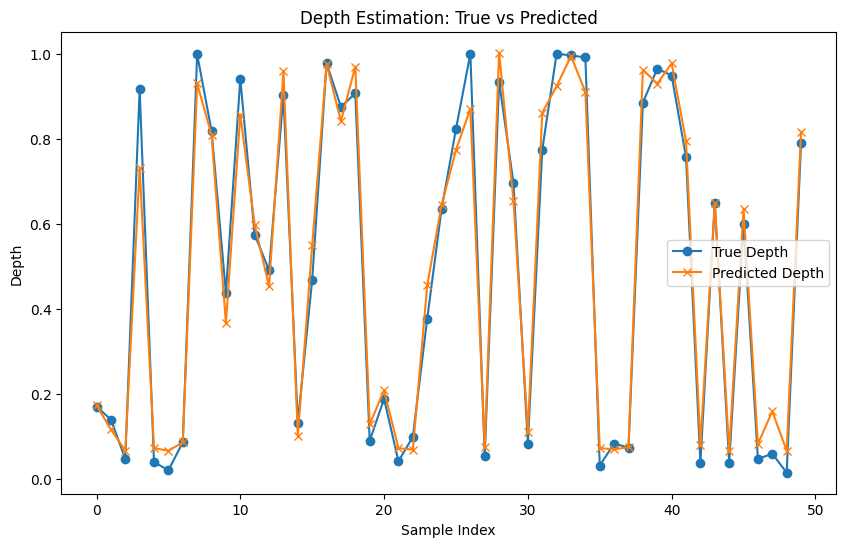

================Results for Resnet-18================


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
<ipython-input-20-9e114c9a3726>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more detai

Test Loss: 0.0016

=== Pose Classification Metrics ===
Pitch Classification Accuracy: 1.0000
Roll Classification Accuracy: 1.0000

Pitch Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        90
           1       1.00      1.00      1.00        78
           2       1.00      1.00      1.00        68
           3       1.00      1.00      1.00        57
           4       1.00      1.00      1.00        45
           5       1.00      1.00      1.00        33
           6       1.00      1.00      1.00        22
           7       1.00      1.00      1.00        11

    accuracy                           1.00       404
   macro avg       1.00      1.00      1.00       404
weighted avg       1.00      1.00      1.00       404


Roll Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        

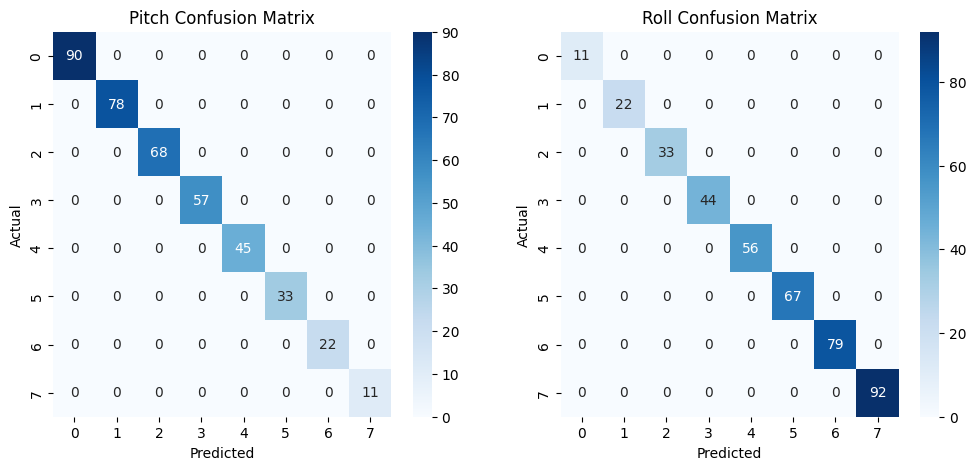

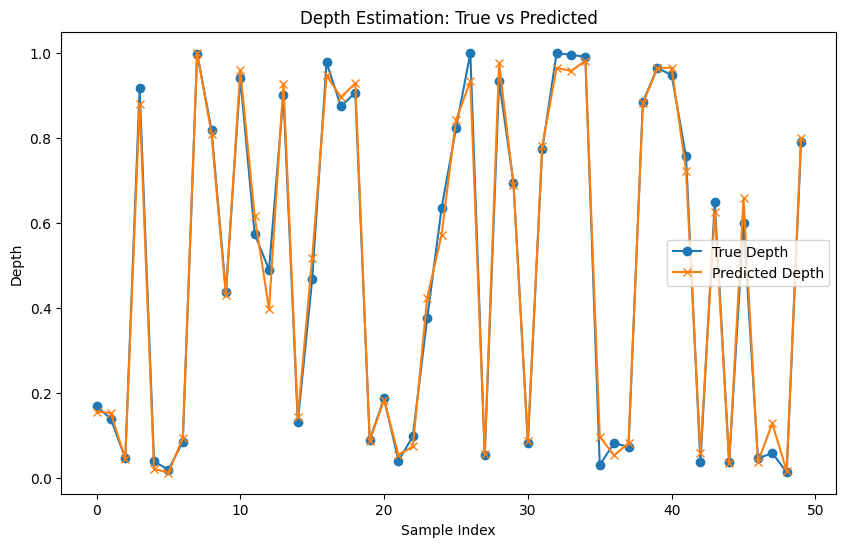

================Results for MobileNetV3================


<ipython-input-20-9e114c9a3726>:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_mobilenetv3_pose_depth.pth'))


Test Loss: 0.0016

=== Pose Classification Metrics ===
Pitch Classification Accuracy: 0.9975
Roll Classification Accuracy: 1.0000

Pitch Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        90
           1       1.00      0.99      0.99        78
           2       1.00      1.00      1.00        68
           3       1.00      1.00      1.00        57
           4       1.00      1.00      1.00        45
           5       1.00      1.00      1.00        33
           6       1.00      1.00      1.00        22
           7       1.00      1.00      1.00        11

    accuracy                           1.00       404
   macro avg       1.00      1.00      1.00       404
weighted avg       1.00      1.00      1.00       404


Roll Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        11
           1       1.00      1.00      1.00        

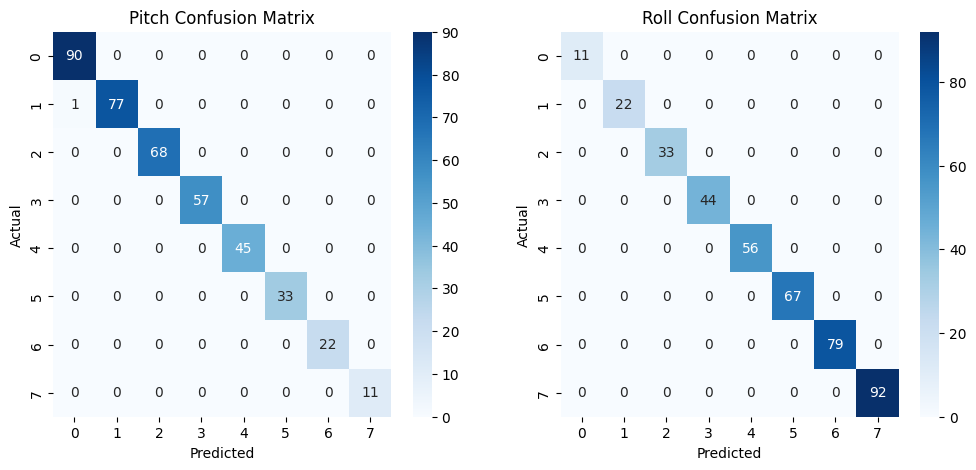

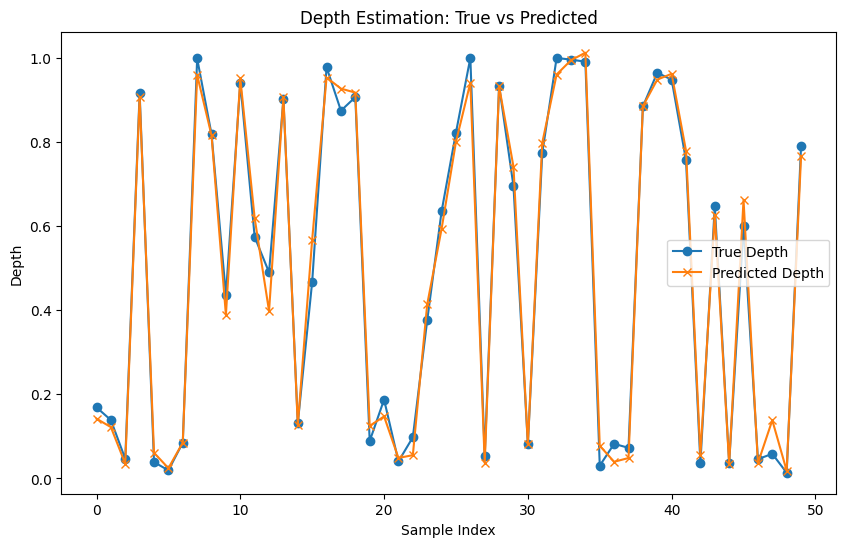

In [ ]:
# Load the best model for PoseDepthNet
print("================Results for PoseDepthNet================")
model = PoseDepthNet() # Instantiate PoseDepthNet model before loading weights
model.to(device)
model.load_state_dict(torch.load('best_pose_depth_model.pth'))
evaluate_on_test(model, test_loader_gray, device)
evaluate_model(model, test_loader_gray, device)

# Load the best model for Resnet-18
print("================Results for Resnet-18================")
model = PoseDepthResNet18(num_pitch_classes=8, num_roll_classes=8, dropout_prob=0.1) # Instantiate PoseDepthResNet18 model before loading weights
model.to(device)
model.load_state_dict(torch.load('best_resnet18_pose_depth.pth'))
evaluate_on_test(model, test_loader_rgb, device)
evaluate_model(model, test_loader_rgb, device)

# Load the best model for MobileNetV3
print("================Results for MobileNetV3================")
model = PoseDepthMobileNetV3(num_pitch_classes=8, num_roll_classes=8, dropout_prob=0.1)  # Instantiate PoseDepthMobileNetV3 model before loading weights
model.to(device)
model.load_state_dict(torch.load('best_mobilenetv3_pose_depth.pth'))
evaluate_on_test(model, test_loader_rgb, device)
evaluate_model(model, test_loader_rgb, device)

## Evaluation Results: Model Performance on Test Dataset

### PoseDepthNet
- **Test Loss**: 0.0044

#### Pose Classification Metrics
- **Pitch Classification Accuracy**: 0.9901
- **Roll Classification Accuracy**: 0.9851

##### Pitch Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.99      | 0.97   | 0.98     | 90      |
| 1     | 0.99      | 0.99   | 0.99     | 78      |
| 2     | 0.97      | 1.00   | 0.99     | 68      |
| 3     | 1.00      | 1.00   | 1.00     | 57      |
| 4     | 1.00      | 1.00   | 1.00     | 45      |
| 5     | 1.00      | 1.00   | 1.00     | 33      |
| 6     | 1.00      | 1.00   | 1.00     | 22      |
| 7     | 1.00      | 1.00   | 1.00     | 11      |

##### Roll Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 1.00      | 0.91   | 0.95     | 11      |
| 1     | 1.00      | 1.00   | 1.00     | 22      |
| 2     | 1.00      | 1.00   | 1.00     | 33      |
| 3     | 0.98      | 0.98   | 0.98     | 44      |
| 4     | 0.98      | 0.98   | 0.98     | 56      |
| 5     | 1.00      | 0.97   | 0.98     | 67      |
| 6     | 0.95      | 1.00   | 0.98     | 79      |
| 7     | 1.00      | 0.99   | 0.99     | 92      |

#### Depth Estimation Metrics
- **Depth MAE**: 0.0443
- **Depth RMSE**: 0.0553
- **Depth R² Score**: 0.9750

---

### ResNet-18
- **Test Loss**: 0.0016

#### Pose Classification Metrics
- **Pitch Classification Accuracy**: 1.0000
- **Roll Classification Accuracy**: 1.0000

##### Pitch Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 1.00      | 1.00   | 1.00     | 90      |
| 1     | 1.00      | 1.00   | 1.00     | 78      |
| 2     | 1.00      | 1.00   | 1.00     | 68      |
| 3     | 1.00      | 1.00   | 1.00     | 57      |
| 4     | 1.00      | 1.00   | 1.00     | 45      |
| 5     | 1.00      | 1.00   | 1.00     | 33      |
| 6     | 1.00      | 1.00   | 1.00     | 22      |
| 7     | 1.00      | 1.00   | 1.00     | 11      |

##### Roll Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 1.00      | 1.00   | 1.00     | 11      |
| 1     | 1.00      | 1.00   | 1.00     | 22      |
| 2     | 1.00      | 1.00   | 1.00     | 33      |
| 3     | 1.00      | 1.00   | 1.00     | 44      |
| 4     | 1.00      | 1.00   | 1.00     | 56      |
| 5     | 1.00      | 1.00   | 1.00     | 67      |
| 6     | 1.00      | 1.00   | 1.00     | 79      |
| 7     | 1.00      | 1.00   | 1.00     | 92      |

#### Depth Estimation Metrics
- **Depth MAE**: 0.0268
- **Depth RMSE**: 0.0363
- **Depth R² Score**: 0.9892

---

### MobileNetV3
- **Test Loss**: 0.0016

#### Pose Classification Metrics
- **Pitch Classification Accuracy**: 0.9975
- **Roll Classification Accuracy**: 1.0000

##### Pitch Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.99      | 1.00   | 0.99     | 90      |
| 1     | 1.00      | 0.99   | 0.99     | 78      |
| 2     | 1.00      | 1.00   | 1.00     | 68      |
| 3     | 1.00      | 1.00   | 1.00     | 57      |
| 4     | 1.00      | 1.00   | 1.00     | 45      |
| 5     | 1.00      | 1.00   | 1.00     | 33      |
| 6     | 1.00      | 1.00   | 1.00     | 22      |
| 7     | 1.00      | 1.00   | 1.00     | 11      |

##### Roll Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 1.00      | 1.00   | 1.00     | 11      |
| 1     | 1.00      | 1.00   | 1.00     | 22      |
| 2     | 1.00      | 1.00   | 1.00     | 33      |
| 3     | 1.00      | 1.00   | 1.00     | 44      |
| 4     | 1.00      | 1.00   | 1.00     | 56      |
| 5     | 1.00      | 1.00   | 1.00     | 67      |
| 6     | 1.00      | 1.00   | 1.00     | 79      |
| 7     | 1.00      | 1.00   | 1.00     | 92      |

#### Depth Estimation Metrics
- **Depth MAE**: 0.0286
- **Depth RMSE**: 0.0376
- **Depth R² Score**: 0.9884


## Exporting Trained Models

### Steps

1. **Create a Zip Archive**:
   - Use Python's `zipfile` module to create an archive named `AllModels.zip`.
   - Include only the specified files in the archive.

2. **Download Archive**:
   - Use the `google.colab` `files` module to download the zip file locally.

In [ ]:
import zipfile

# Specify the files to include in the zip archive
files_to_include = ['best_pose_depth_model.pth', 'best_resnet18_pose_depth.pth', 'best_mobilenetv3_pose_depth.pth']

# Create a zip archive containing only the specified files
with zipfile.ZipFile('AllModels.zip', 'w') as archive:
    for file in files_to_include:
        archive.write(file)

from google.colab import files
files.download('AllModels.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>